In [5]:
from google.colab import files
uploaded = files.upload()

Saving Metro_Interstate_Traffic_Volume.csv to Metro_Interstate_Traffic_Volume.csv


In [6]:
import pandas as pd
df=pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [7]:
print(df.isnull().sum())

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


In [9]:
df['holiday']=df['holiday'].fillna('None')

In [11]:
df['date_time']=pd.to_datetime(df['date_time'])
df['year']=df['date_time'].dt.year
df["month"] = df["date_time"].dt.month
df["day"] = df["date_time"].dt.day
df["hour"] = df["date_time"].dt.hour
df["weekday"] = df["date_time"].dt.weekday

df.drop("date_time", axis=1, inplace=True)

In [12]:
df=pd.get_dummies(df,drop_first=True)

In [13]:
X=df.drop('traffic_volume',axis=1)
y=df['traffic_volume']

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

Random Forest Regression

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf=RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

rf_mae=mean_absolute_error(y_test,rf_pred)
rf_r2=r2_score(y_test,rf_pred)

print(rf_mae)
print(rf_r2*100)

203.28631988382946
96.44234869318315


96% accuracy is obtained by using the Random Forest Regression Model

AdaBoost Regression

In [17]:
from sklearn.ensemble import AdaBoostRegressor
ada=AdaBoostRegressor(n_estimators=100, random_state=42)
ada.fit(X_train,y_train)
ada_pred=ada.predict(X_test)

ada_mae=mean_absolute_error(y_test,ada_pred)
ada_r2=r2_score(y_test,ada_pred)

print(ada_mae)
print(ada_r2*100)


630.7644784712593
82.1345606628024


82% accuracy is obtained by using the AdaBoost regresion model

XG Boost Regression

In [18]:
from xgboost import XGBRegressor

xgb=XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)

xgb_mae=mean_absolute_error(y_test,xgb_pred)
xgb_r2=r2_score(y_test,xgb_pred)

print(xgb_mae)
print(xgb_r2*100)


225.52255249023438
96.38915061950684


96% accuracy is obtained by using the XG Boost Regression Model

Performance Comparision

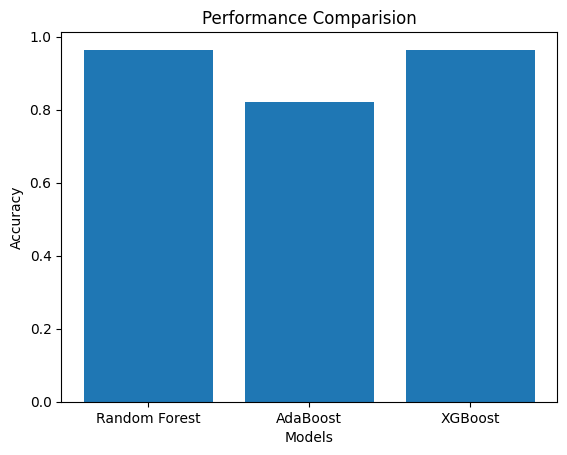

In [19]:
import matplotlib.pyplot as plt

models=['Random Forest', 'AdaBoost','XGBoost']
scores=[rf_r2,ada_r2,xgb_r2]

plt.bar(models,scores)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Performance Comparision')
plt.show()

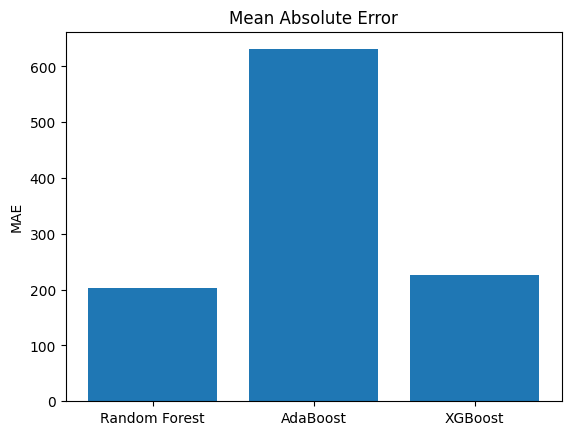

In [20]:
mae = [rf_mae, ada_mae, xgb_mae]

plt.bar(models, mae)

plt.title("Mean Absolute Error")
plt.ylabel("MAE")

plt.show()

**SUMMARY**

1. Random Forest
- a learning algorithm that builds multiple decision trees and combines thier predictions.

- uses the Bagging( Bootstrap Aggregating) technique.

- takes random samples from dataset and out of the multiple trees created, each tree amkes a prediction

- final prediction is majority voting for classification and avg of predictions for regresssion.

- high accuracy, reduces overfitting, best suited for regression and classification problems.


2. AdaBoost
- a boosting algorithm that combines several weak learners into one strong model
- it first trains the weak learner, them identifies incorrectly predictyed samples, train the next learner focusing more on those difficult samples and repeats the process.
- simple to implement, fast training, best suited for small and medium sized datasets and clean datasets with  fewer outliers.

3. XGBoost(Extreme Gradient Boosting)
- an advanced implementation of Gradient Boosting designed for speed, efficiency and high accuracy
- works by building trees separately,  each tree learns from the errors made by previous trees, uses gradient descent to minimize loss, includees regularization to prevent overfitting
- very high accuracy and handles missing values automatically, and fast and scalable
- best suited for large datasets, treal world predictive analysis
